In [5]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
DB_PATH = "data/uber_warehouse.db"

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(
        "uber_warehouse.db not found. Run etl.py first."
    )

conn = sqlite3.connect(DB_PATH)


def q(sql):
    return pd.read_sql_query(sql, conn)


sns.set_theme(style="whitegrid")

In [7]:
total = q("""
    SELECT COUNT(*) AS total_trips
    FROM fact_trips
""")["total_trips"].iloc[0]

print("=" * 60)
print("UBER NYC PICKUPS ANALYSIS")
print("=" * 60)

print(f"\nTotal trips: {total:,}")

UBER NYC PICKUPS ANALYSIS

Total trips: 4,443,196


In [9]:
total = q("""
    SELECT COUNT(*) AS total_trips
    FROM fact_trips
""")["total_trips"].iloc[0]

print("=" * 60)
print("UBER NYC PICKUPS ANALYSIS")
print("=" * 60)

print(f"\nTotal trips: {total:,}")



UBER NYC PICKUPS ANALYSIS

Total trips: 4,443,196


In [10]:

print("\n" + "=" * 60)
print("1. TRIPS BY HOUR")
print("=" * 60)

hourly = q("""
    SELECT
        hour,
        COUNT(*) AS trips
    FROM fact_trips
    GROUP BY hour
    ORDER BY hour
""")

print(hourly.to_string(index=False))

peak = hourly.loc[hourly["trips"].idxmax()]
quiet = hourly.loc[hourly["trips"].idxmin()]

print(
    f"\nPeak hour: {int(peak['hour'])}:00 "
    f"({int(peak['trips']):,} trips)"
)

print(
    f"Quietest hour: {int(quiet['hour'])}:00 "
    f"({int(quiet['trips']):,} trips)"
)


1. TRIPS BY HOUR
 hour  trips
    0 101469
    1  65700
    2  44781
    3  47262
    4  54137
    5  82232
    6 140456
    7 189499
    8 186947
    9 157051
   10 156103
   11 162324
   12 166955
   13 191943
   14 226001
   15 270137
   16 307237
   17 329489
   18 318116
   19 288377
   20 278816
   21 275597
   22 236899
   23 165668

Peak hour: 17:00 (329,489 trips)
Quietest hour: 2:00 (44,781 trips)


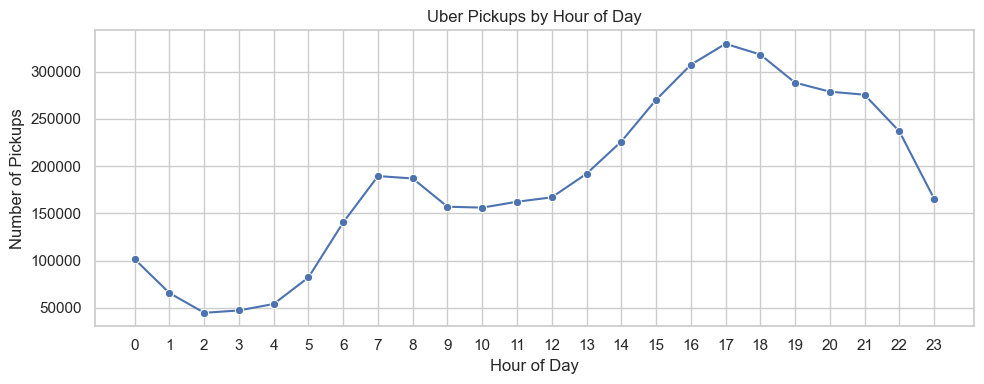

In [11]:

plt.figure(figsize=(10, 4))

sns.lineplot(
    data=hourly,
    x="hour",
    y="trips",
    marker="o"
)

plt.title("Uber Pickups by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [12]:

print("\n" + "=" * 60)
print("2. WEEKDAY × HOUR")
print("=" * 60)

heat = q("""
    SELECT
        weekday_num,
        weekday_name,
        hour,
        COUNT(*) AS trips
    FROM fact_trips
    GROUP BY weekday_num, weekday_name, hour
    ORDER BY weekday_num, hour
""")

print(heat.to_string(index=False))



2. WEEKDAY × HOUR
 weekday_num weekday_name  hour  trips
           0          Mon     0   6309
           0          Mon     1   3670
           0          Mon     2   2880
           0          Mon     3   6095
           0          Mon     4   9433
           0          Mon     5  14709
           0          Mon     6  23269
           0          Mon     7  30617
           0          Mon     8  28727
           0          Mon     9  21814
           0          Mon    10  19900
           0          Mon    11  19932
           0          Mon    12  20063
           0          Mon    13  22948
           0          Mon    14  27636
           0          Mon    15  32151
           0          Mon    16  38083
           0          Mon    17  41305
           0          Mon    18  36311
           0          Mon    19  33463
           0          Mon    20  32245
           0          Mon    21  28361
           0          Mon    22  19776
           0          Mon    23  11569
      

In [13]:
# Create heatmap table
pivot = heat.pivot(
    index="weekday_name",
    columns="hour",
    values="trips"
)

weekday_order = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun"
]

available_days = [
    day for day in weekday_order
    if day in pivot.index
]

pivot = pivot.loc[available_days]


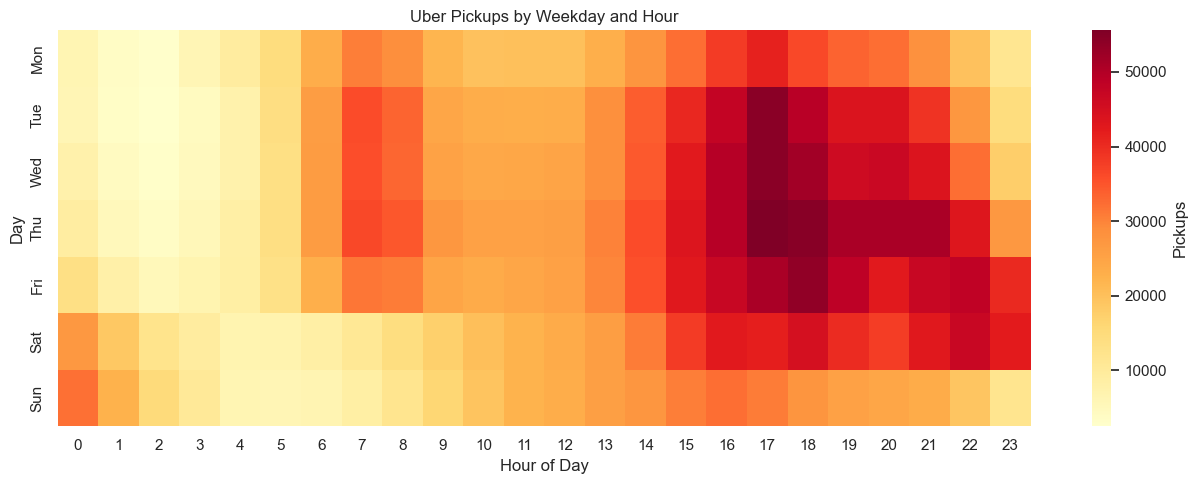

In [14]:
plt.figure(figsize=(13, 5))

sns.heatmap(
    pivot,
    cmap="YlOrRd",
    cbar_kws={"label": "Pickups"}
)

plt.title("Uber Pickups by Weekday and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day")

plt.tight_layout()
plt.show()

In [15]:


print("\n" + "=" * 60)
print("3. MONTHLY TREND")
print("=" * 60)

monthly = q("""
    SELECT
        month,
        month_name,
        COUNT(*) AS trips
    FROM fact_trips
    GROUP BY month, month_name
    ORDER BY month
""")

monthly["growth_pct"] = (
    monthly["trips"]
    .pct_change()
    .mul(100)
    .round(1)
)

print(
    monthly[
        ["month_name", "trips", "growth_pct"]
    ].to_string(index=False)
)



3. MONTHLY TREND
month_name   trips  growth_pct
       Apr  556143         NaN
       May  641435        15.3
       Jun  652002         1.6
       Jul  780179        19.7
       Aug  811247         4.0
       Sep 1002190        23.5


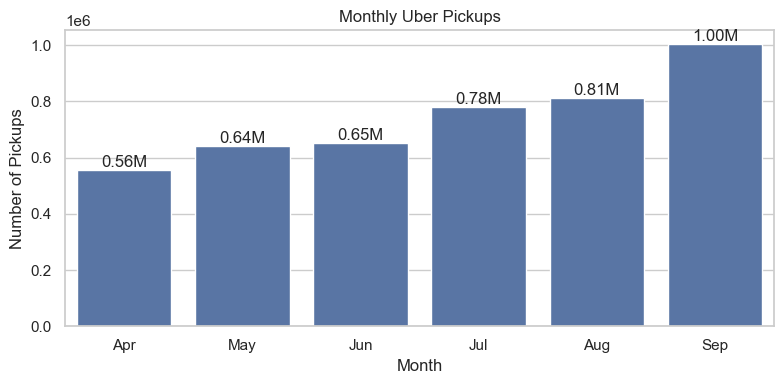

In [16]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=monthly,
    x="month_name",
    y="trips"
)

for i, row in monthly.iterrows():

    ax.text(
        i,
        row["trips"],
        f"{row['trips'] / 1e6:.2f}M",
        ha="center",
        va="bottom"
    )

plt.title("Monthly Uber Pickups")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")

plt.tight_layout()
plt.show()

In [17]:
print("\n" + "=" * 60)
print("4. TRIPS BY DISPATCH BASE")
print("=" * 60)

bases = q("""
    SELECT
        b.base_code,
        COUNT(*) AS trips
    FROM fact_trips f
    JOIN dim_base b
        ON f.base_id = b.base_id
    GROUP BY b.base_code
    ORDER BY trips DESC
""")

bases["percentage"] = (
    100 * bases["trips"] / bases["trips"].sum()
).round(2)

print(
    bases.to_string(index=False)
)


4. TRIPS BY DISPATCH BASE
base_code   trips  percentage
   B02617 1415714       31.86
   B02598 1377194       31.00
   B02682 1196598       26.93
   B02764  254480        5.73
   B02512  199210        4.48


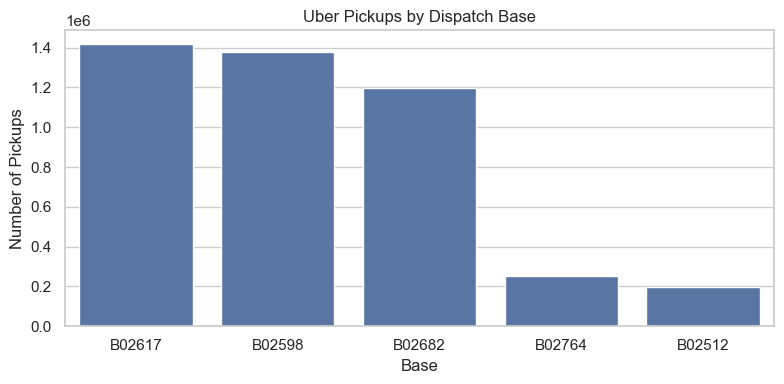

In [18]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=bases,
    x="base_code",
    y="trips"
)

plt.title("Uber Pickups by Dispatch Base")
plt.xlabel("Base")
plt.ylabel("Number of Pickups")

plt.tight_layout()
plt.show()

In [21]:
print("\n" + "=" * 60)
print("5. WEEKDAY VS WEEKEND")
print("=" * 60)

daytype = q("""
    SELECT
        is_weekend,
        COUNT(*) AS trips,
        COUNT(DISTINCT date_id) AS days
    FROM fact_trips
    GROUP BY is_weekend
""")

daytype["day_type"] = daytype["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

daytype["avg_trips_per_day"] = (
    daytype["trips"] / daytype["days"]
).round(0)

print(
    daytype[
        [
            "day_type",
            "days",
            "trips",
            "avg_trips_per_day"
        ]
    ].to_string(index=False)
)


5. WEEKDAY VS WEEKEND
day_type  days   trips  avg_trips_per_day
 Weekday   131 3330907            25427.0
 Weekend    52 1112289            21390.0


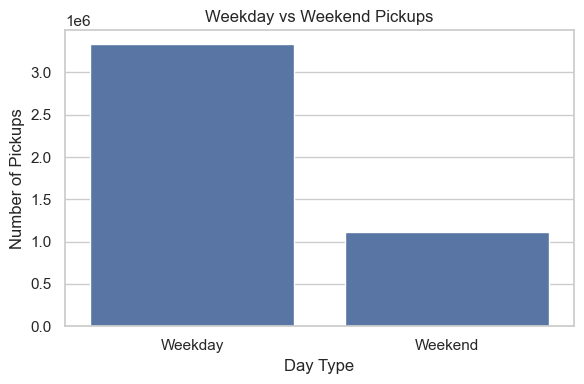

In [22]:

plt.figure(figsize=(6, 4))

sns.barplot(
    data=daytype,
    x="day_type",
    y="trips"
)

plt.title("Weekday vs Weekend Pickups")
plt.xlabel("Day Type")
plt.ylabel("Number of Pickups")

plt.tight_layout()
plt.show()

In [23]:
print("\n" + "=" * 60)
print("6. DAILY TREND")
print("=" * 60)

daily = q("""
    SELECT
        d.trip_date,
        COUNT(*) AS trips
    FROM fact_trips f
    JOIN dim_date d
        ON f.date_id = d.date_id
    GROUP BY d.trip_date
    ORDER BY d.trip_date
""")

daily["trip_date"] = pd.to_datetime(
    daily["trip_date"]
)

print(daily.to_string(index=False))



6. DAILY TREND
 trip_date  trips
2014-04-01  14355
2014-04-02  17208
2014-04-03  20452
2014-04-04  26335
2014-04-05  19256
2014-04-06  13233
2014-04-07  19296
2014-04-08  15976
2014-04-09  16609
2014-04-10  19762
2014-04-11  20108
2014-04-12  17898
2014-04-13  11935
2014-04-14  12493
2014-04-15  20343
2014-04-16  17472
2014-04-17  20679
2014-04-18  17787
2014-04-19  14382
2014-04-20  10864
2014-04-21  12964
2014-04-22  16696
2014-04-23  20021
2014-04-24  22969
2014-04-25  24663
2014-04-26  24522
2014-04-27  14436
2014-04-28  15250
2014-04-29  22494
2014-04-30  35685
2014-05-01  22970
2014-05-02  23875
2014-05-03  21942
2014-05-04  13648
2014-05-05  17591
2014-05-06  18997
2014-05-07  21456
2014-05-08  27038
2014-05-09  25920
2014-05-10  22117
2014-05-11  14585
2014-05-12  17173
2014-05-13  19173
2014-05-14  21784
2014-05-15  25848
2014-05-16  31995
2014-05-17  21941
2014-05-18  16224
2014-05-19  18055
2014-05-20  20518
2014-05-21  23092
2014-05-22  26381
2014-05-23  25964
2014-05-24  

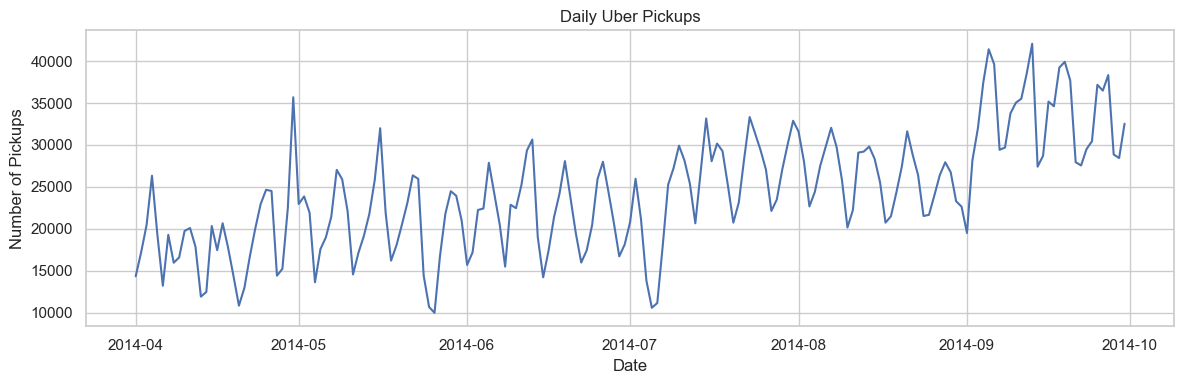

In [24]:
plt.figure(figsize=(12, 4))

sns.lineplot(
    data=daily,
    x="trip_date",
    y="trips"
)

plt.title("Daily Uber Pickups")
plt.xlabel("Date")
plt.ylabel("Number of Pickups")

plt.tight_layout()
plt.show()

In [25]:

print("\n" + "=" * 60)
print("7. PICKUP HOTSPOTS")
print("=" * 60)

spots = q("""
    SELECT
        ROUND(lat, 2) AS lat_bin,
        ROUND(lon, 2) AS lon_bin,
        COUNT(*) AS trips
    FROM fact_trips
    GROUP BY lat_bin, lon_bin
    ORDER BY trips DESC
    LIMIT 20
""")

print(spots.to_string(index=False))



7. PICKUP HOTSPOTS
 lat_bin  lon_bin  trips
   40.76   -73.98 221153
   40.76   -73.97 211751
   40.74   -73.99 187292
   40.75   -73.99 169186
   40.72   -74.00 162636
   40.73   -74.00 158995
   40.75   -73.98 156922
   40.73   -73.99 141826
   40.74   -74.00 132137
   40.76   -73.99 118202
   40.72   -73.99 108664
   40.72   -74.01 105321
   40.71   -74.01 101701
   40.74   -74.01  98680
   40.77   -73.96  85785
   40.74   -73.98  81525
   40.77   -73.98  80687
   40.73   -74.01  72178
   40.73   -73.98  71140
   40.75   -73.97  68751


In [26]:
try:

    fig = px.scatter_map(
        spots,
        lat="lat_bin",
        lon="lon_bin",
        size="trips",
        color="trips",
        zoom=10,
        map_style="carto-positron",
        title="Uber Pickup Hotspots"
    )

except AttributeError:

    fig = px.scatter_mapbox(
        spots,
        lat="lat_bin",
        lon="lon_bin",
        size="trips",
        color="trips",
        zoom=10,
        mapbox_style="carto-positron",
        title="Uber Pickup Hotspots"
    )

fig.show()

In [28]:
print("\n" + "=" * 60)
print("8. MONTH-OVER-MONTH GROWTH")
print("=" * 60)

growth = q("""
    WITH m AS (
        SELECT
            month,
            month_name,
            COUNT(*) AS trips
        FROM fact_trips
        GROUP BY month, month_name
    )

    SELECT
        month_name,
        trips,
        ROUND(
            100.0 *
            (trips - LAG(trips) OVER (ORDER BY month))
            /
            LAG(trips) OVER (ORDER BY month),
            1
        ) AS growth_pct

    FROM m
    ORDER BY month
""")

print(growth.to_string(index=False))




8. MONTH-OVER-MONTH GROWTH
month_name   trips  growth_pct
       Apr  556143         NaN
       May  641435        15.3
       Jun  652002         1.6
       Jul  780179        19.7
       Aug  811247         4.0
       Sep 1002190        23.5


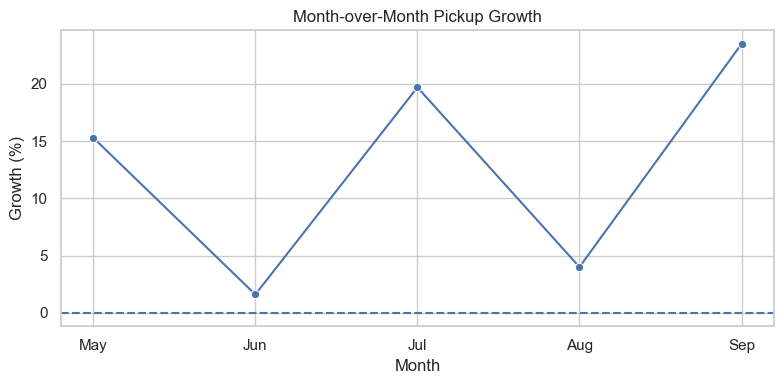

In [29]:


plt.figure(figsize=(8, 4))

sns.lineplot(
    data=growth.iloc[1:],
    x="month_name",
    y="growth_pct",
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Month-over-Month Pickup Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.tight_layout()
plt.show()

In [31]:
print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Top base
top_base = bases.iloc[0]

# First and last month
first = monthly.iloc[0]
last = monthly.iloc[-1]

# Weekday/weekend
wk = daytype.set_index("day_type")[
    "avg_trips_per_day"
]

# Top location
top_cell = spots.iloc[0]

print(
    f"\n1. Peak pickup hour: "
    f"{int(peak['hour'])}:00"
)

print(
    f"2. Quietest pickup hour: "
    f"{int(quiet['hour'])}:00"
)

if "Weekday" in wk.index and "Weekend" in wk.index:

    print(
        f"3. Average weekday pickups/day: "
        f"{wk['Weekday']:,.0f}"
    )

    print(
        f"   Average weekend pickups/day: "
        f"{wk['Weekend']:,.0f}"
    )

print(
    f"4. Top dispatch base: "
    f"{top_base['base_code']} "
    f"({top_base['percentage']:.2f}% of trips)"
)

overall_growth = (
    100 * (last["trips"] / first["trips"] - 1)
)

print(
    f"5. Change from {first['month_name']} "
    f"to {last['month_name']}: "
    f"{overall_growth:.1f}%"
)

print(
    f"6. Top pickup area: "
    f"({top_cell['lat_bin']}, {top_cell['lon_bin']}) "
    f"with {int(top_cell['trips']):,} trips"
)



KEY FINDINGS

1. Peak pickup hour: 17:00
2. Quietest pickup hour: 2:00
3. Average weekday pickups/day: 25,427
   Average weekend pickups/day: 21,390
4. Top dispatch base: B02617 (31.86% of trips)
5. Change from Apr to Sep: 80.2%
6. Top pickup area: (40.76, -73.98) with 221,153 trips
